<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/04_weight_initializations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04 — Weight Initializations

## What This Notebook Covers
How you initialize the weights of a neural network before training has a
surprisingly large effect on whether training succeeds at all.

Bad initialization causes two classic failure modes:
- **Vanishing gradients** — activations collapse toward zero, gradients become
  tiny, early layers stop learning
- **Exploding gradients** — activations and gradients grow exponentially,
  training diverges

Good initialization keeps the signal flowing through the network at a
reasonable scale from the very first forward pass.

**Initializations covered:**
- Zeros (what NOT to do)
- Random Normal (naive baseline)
- Glorot / Xavier Uniform & Normal (default for tanh/sigmoid)
- He / Kaiming Normal & Uniform (default for ReLU family)
- LeCun Normal (designed for SELU)
- Orthogonal (useful for RNNs)

**Both TensorFlow and PyTorch implementations are shown.**

**Dataset:** Fashion-MNIST


## Part A — TensorFlow / Keras Implementation

In [1]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data — TensorFlow


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]
print('TF data ready.')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
TF data ready.


## 2. The Problem: Why Initialization Matters

Before training anything, let us visualize what happens to activations
in the very first forward pass under different initializations.
If activations are near zero or exploding on pass #1, training will struggle.


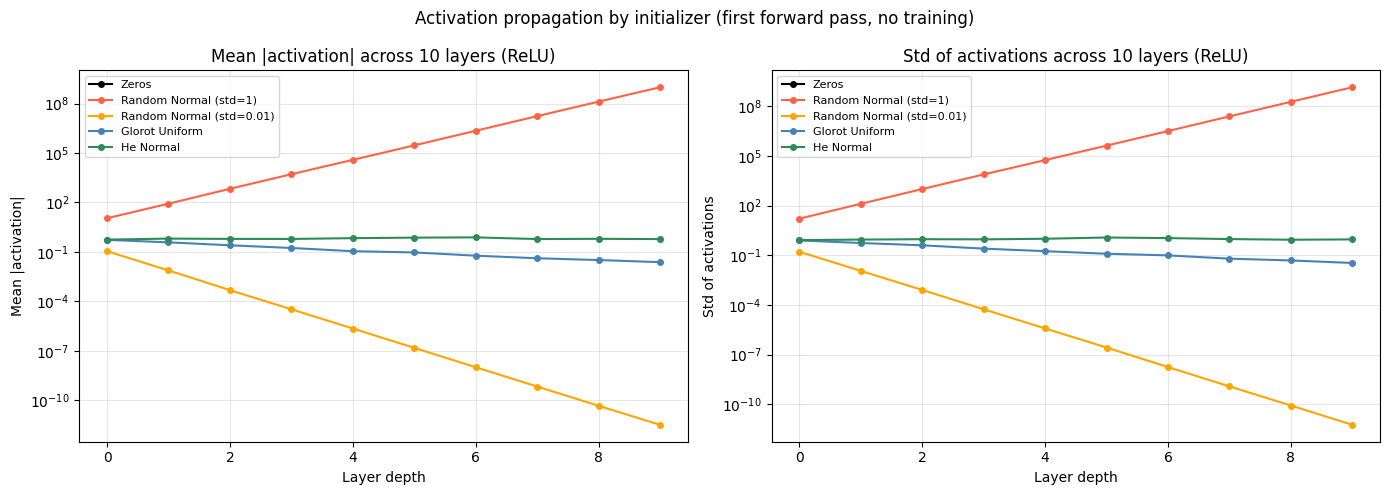

Zeros      -> all activations zero (dead network)
Std=1.0    -> activations explode
Std=0.01   -> activations vanish
Glorot     -> stable but slightly low for ReLU
He Normal  -> stable across all 10 layers with ReLU


In [3]:
def get_activation_stats(init_name, initializer, activation='relu', n_layers=10):
    """
    Build a deep network with a given initializer, run one forward pass
    on random data, and collect the mean and std of activations at each layer.
    This shows whether the signal propagates cleanly or vanishes/explodes.
    """
    tf.random.set_seed(0)
    x = tf.random.normal([256, 784])   # simulate a batch of flattened images

    means, stds = [], []
    for _ in range(n_layers):
        layer = tf.keras.layers.Dense(
            100,
            activation=activation,
            kernel_initializer=initializer
        )
        x = layer(x)
        means.append(float(tf.reduce_mean(tf.abs(x)).numpy()))
        stds.append(float(tf.math.reduce_std(x).numpy()))

    return means, stds


# Compare initializations with ReLU activation
init_configs_relu = [
    ('Zeros',          'zeros'),
    ('Random Normal (std=1)', tf.initializers.RandomNormal(stddev=1.0)),
    ('Random Normal (std=0.01)', tf.initializers.RandomNormal(stddev=0.01)),
    ('Glorot Uniform', 'glorot_uniform'),
    ('He Normal',      'he_normal'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['black', 'tomato', 'orange', 'steelblue', 'seagreen']
for (name, init), color in zip(init_configs_relu, colors):
    means, stds = get_activation_stats(name, init, activation='relu')
    axes[0].plot(means, label=name, color=color, marker='o', markersize=4)
    axes[1].plot(stds,  label=name, color=color, marker='o', markersize=4)

axes[0].set_title('Mean |activation| across 10 layers (ReLU)')
axes[0].set_xlabel('Layer depth')
axes[0].set_ylabel('Mean |activation|')
axes[0].legend(fontsize=8)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Std of activations across 10 layers (ReLU)')
axes[1].set_xlabel('Layer depth')
axes[1].set_ylabel('Std of activations')
axes[1].legend(fontsize=8)
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Activation propagation by initializer (first forward pass, no training)', fontsize=12)
plt.tight_layout()
plt.show()

print('Zeros      -> all activations zero (dead network)')
print('Std=1.0    -> activations explode')
print('Std=0.01   -> activations vanish')
print('Glorot     -> stable but slightly low for ReLU')
print('He Normal  -> stable across all 10 layers with ReLU')

## 3. Why Zeros is the Worst Possible Initialization

All weights zero means all neurons in a layer produce identical outputs.
All gradients are also identical so all weights update identically.
The network never breaks symmetry — all neurons learn the same thing forever.
This is called the **symmetry breaking problem**.


In [4]:
def make_model_tf(initializer, activation='relu'):
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(256, activation=activation, kernel_initializer=initializer),
        tf.keras.layers.Dense(128, activation=activation, kernel_initializer=initializer),
        tf.keras.layers.Dense(64,  activation=activation, kernel_initializer=initializer),
        tf.keras.layers.Dense(10,  activation='softmax'),
    ])


def quick_train_tf(model, epochs=10, label=''):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs, batch_size=64, verbose=0
    )
    best_val = max(history.history['val_accuracy'])
    print(f'{label:40s} -> best val accuracy: {best_val:.4f}')
    return history


print('Training with Zeros initializer (expect near-random accuracy)...')
zeros_model = make_model_tf('zeros')
quick_train_tf(zeros_model, label='Zeros initializer')

print()
print('Training with He Normal (correct for ReLU)...')
he_model = make_model_tf('he_normal')
quick_train_tf(he_model, label='He Normal initializer')

Training with Zeros initializer (expect near-random accuracy)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Zeros initializer                        -> best val accuracy: 0.0986

Training with He Normal (correct for ReLU)...
He Normal initializer                    -> best val accuracy: 0.8878


## 4. Full A/B Comparison — All Initializers with ReLU

We train the same architecture from scratch with each initializer and
compare validation accuracy curves.


Training each initializer for 15 epochs with ReLU activation...
Random Normal (std=0.01)                 -> best val accuracy: 0.8982
Glorot Uniform (Xavier)                  -> best val accuracy: 0.8994
Glorot Normal                            -> best val accuracy: 0.8938
He Uniform                               -> best val accuracy: 0.8956
He Normal                                -> best val accuracy: 0.8968
Orthogonal                               -> best val accuracy: 0.8974


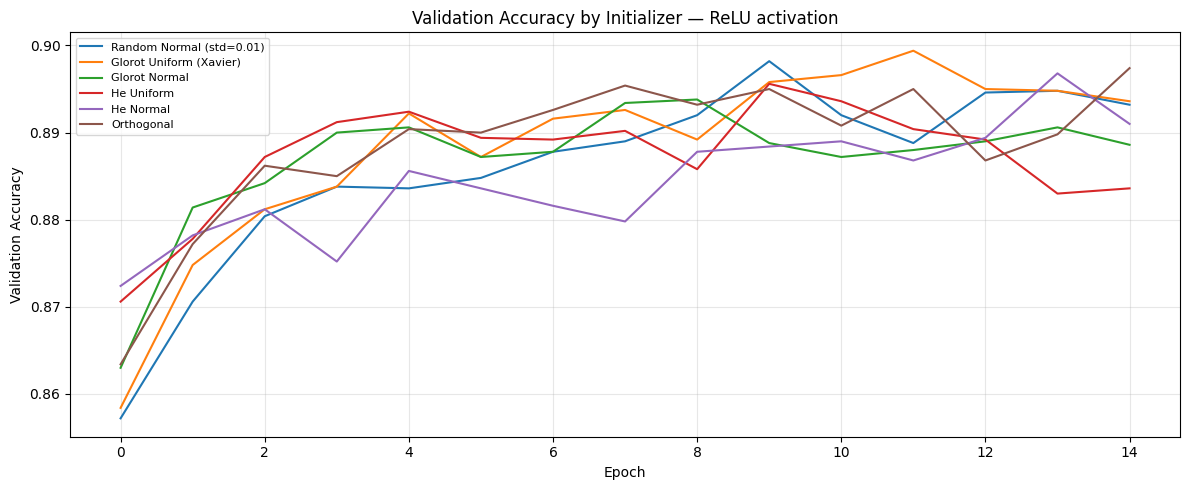

In [5]:
EPOCHS = 15

initializers_relu = {
    'Random Normal (std=0.01)': tf.initializers.RandomNormal(stddev=0.01),
    'Glorot Uniform (Xavier)' : 'glorot_uniform',
    'Glorot Normal'           : 'glorot_normal',
    'He Uniform'              : 'he_uniform',
    'He Normal'               : 'he_normal',
    'Orthogonal'              : 'orthogonal',
}

histories_relu = {}
print('Training each initializer for', EPOCHS, 'epochs with ReLU activation...')

for name, init in initializers_relu.items():
    tf.random.set_seed(42)
    model = make_model_tf(init, activation='relu')
    h = quick_train_tf(model, epochs=EPOCHS, label=name)
    histories_relu[name] = h

# Plot validation accuracy curves
plt.figure(figsize=(12, 5))
for name, h in histories_relu.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.title('Validation Accuracy by Initializer — ReLU activation')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Glorot vs He: The Math Behind the Choice

Both Glorot and He set the initial weight scale based on the number of
input and output connections of a layer (fan_in and fan_out).

**Glorot (Xavier) Normal:**
```
std = sqrt(2 / (fan_in + fan_out))
```
Designed to keep variance equal in both the forward and backward pass.
Works well for **tanh** and **sigmoid** activations.

**He (Kaiming) Normal:**
```
std = sqrt(2 / fan_in)
```
The factor of 2 accounts for ReLU zeroing out half of its inputs.
Works well for **ReLU, Leaky ReLU, ELU** activations.

**LeCun Normal:**
```
std = sqrt(1 / fan_in)
```
Designed for **SELU** activation which has self-normalizing properties.


Layer: 256 -> 128
  fan_in  = 256
  fan_out = 128

  Glorot std = sqrt(2 / (256+128)) = 0.0722  <- use with tanh/sigmoid
  He     std = sqrt(2 / 256)             = 0.0884  <- use with ReLU
  LeCun  std = sqrt(1 / 256)             = 0.0625  <- use with SELU



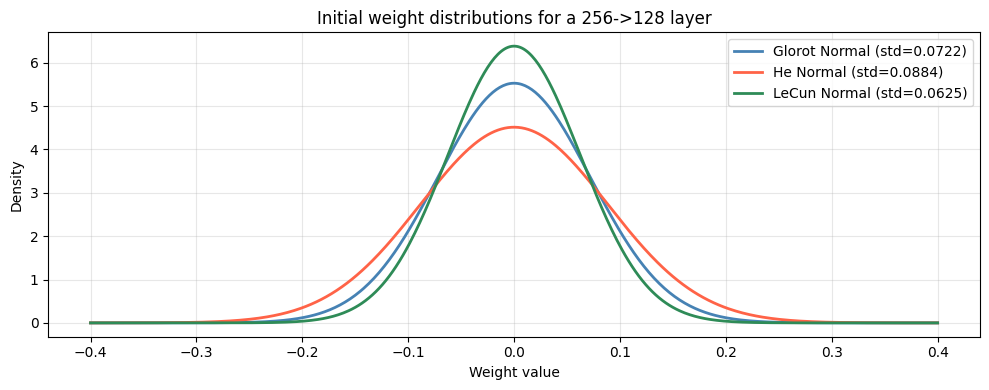

In [6]:
# Demonstrate fan_in / fan_out values for a layer
demo_layer = tf.keras.layers.Dense(128, kernel_initializer='glorot_uniform')
demo_layer.build((None, 256))   # input size 256

fan_in  = 256
fan_out = 128

glorot_std = np.sqrt(2.0 / (fan_in + fan_out))
he_std     = np.sqrt(2.0 / fan_in)
lecun_std  = np.sqrt(1.0 / fan_in)

print(f'Layer: 256 -> 128')
print(f'  fan_in  = {fan_in}')
print(f'  fan_out = {fan_out}')
print()
print(f'  Glorot std = sqrt(2 / ({fan_in}+{fan_out})) = {glorot_std:.4f}  <- use with tanh/sigmoid')
print(f'  He     std = sqrt(2 / {fan_in})             = {he_std:.4f}  <- use with ReLU')
print(f'  LeCun  std = sqrt(1 / {fan_in})             = {lecun_std:.4f}  <- use with SELU')
print()

# Visualise the resulting weight distributions
fig, ax = plt.subplots(figsize=(10, 4))
x = np.linspace(-0.4, 0.4, 500)
for std, label, color in [
    (glorot_std, 'Glorot Normal', 'steelblue'),
    (he_std,     'He Normal',     'tomato'),
    (lecun_std,  'LeCun Normal',  'seagreen'),
]:
    pdf = np.exp(-0.5 * (x / std) ** 2) / (std * np.sqrt(2 * np.pi))
    ax.plot(x, pdf, label=f'{label} (std={std:.4f})', color=color, linewidth=2)

ax.set_title('Initial weight distributions for a 256->128 layer')
ax.set_xlabel('Weight value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Activation-Initializer Pairing Comparison

The right initializer depends on the activation function.
Here we compare three correct pairings against three wrong pairings.


In [7]:
pairings = [
    # (label, activation, initializer, correct?)
    ('He + ReLU (correct)',      'relu',  'he_normal',      True),
    ('Glorot + ReLU (wrong)',    'relu',  'glorot_uniform', False),
    ('Glorot + tanh (correct)',  'tanh',  'glorot_uniform', True),
    ('He + tanh (wrong)',        'tanh',  'he_normal',      False),
    ('LeCun + selu (correct)',   'selu',  'lecun_normal',   True),
    ('He + selu (wrong)',        'selu',  'he_normal',      False),
]

print(f'{"Pairing":40s} | Best Val Acc | Correct pairing?')
print('-' * 70)

results = []
for label, act, init, correct in pairings:
    tf.random.set_seed(42)
    model = make_model_tf(init, activation=act)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    h = model.fit(X_train, y_train,
                  validation_data=(X_valid, y_valid),
                  epochs=10, batch_size=64, verbose=0)
    best = max(h.history['val_accuracy'])
    marker = 'YES' if correct else 'no'
    print(f'{label:40s} | {best:.4f}       | {marker}')
    results.append((label, best, correct))

print()
print('Correct pairings consistently outperform incorrect ones.')

Pairing                                  | Best Val Acc | Correct pairing?
----------------------------------------------------------------------
He + ReLU (correct)                      | 0.8972       | YES
Glorot + ReLU (wrong)                    | 0.8940       | no
Glorot + tanh (correct)                  | 0.8942       | YES
He + tanh (wrong)                        | 0.8856       | no
LeCun + selu (correct)                   | 0.8850       | YES
He + selu (wrong)                        | 0.8890       | no

Correct pairings consistently outperform incorrect ones.


## 7. Orthogonal Initialization

Orthogonal initialization creates a weight matrix where the columns are
orthonormal vectors. This preserves the length of the input vector exactly
during the forward pass (no amplification, no shrinkage).

It is particularly useful for **RNNs and LSTMs** because gradients must
flow through many time steps (equivalent to many layer passes).
Orthogonal weights prevent those gradients from vanishing or exploding
across time steps.


Orthogonal matrix property check: W^T @ W == Identity
Max deviation from identity: 5.96e-07  (should be near zero)

Input  vector norm: 7.2838
Output vector norm: 7.2838
Norms are equal — orthogonal matrix preserves vector length.



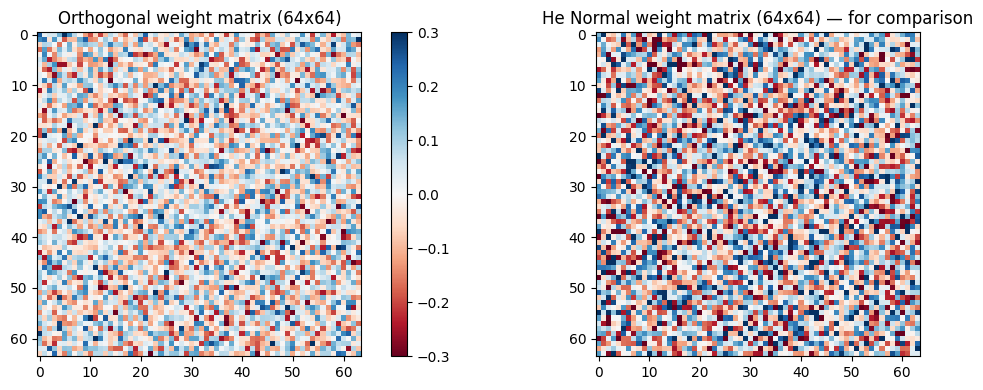

In [8]:
# Demonstrate the orthogonality property
orth_init = tf.initializers.Orthogonal()
W = orth_init(shape=(64, 64)).numpy()

# W^T @ W should be the identity matrix for a square orthogonal matrix
WtW = W.T @ W
identity_error = np.abs(WtW - np.eye(64)).max()

print('Orthogonal matrix property check: W^T @ W == Identity')
print(f'Max deviation from identity: {identity_error:.2e}  (should be near zero)')
print()

# Show that input vector length is preserved
v = np.random.randn(64)
v_out = W @ v
print(f'Input  vector norm: {np.linalg.norm(v):.4f}')
print(f'Output vector norm: {np.linalg.norm(v_out):.4f}')
print('Norms are equal — orthogonal matrix preserves vector length.')
print()

# Visualize the weight matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(W, cmap='RdBu', vmin=-0.3, vmax=0.3)
axes[0].set_title('Orthogonal weight matrix (64x64)')
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])

he_W = tf.initializers.HeNormal()(shape=(64, 64)).numpy()
axes[1].imshow(he_W, cmap='RdBu', vmin=-0.3, vmax=0.3)
axes[1].set_title('He Normal weight matrix (64x64) — for comparison')

plt.tight_layout()
plt.show()

## 8. Quick Reference: When to Use What


In [9]:
reference = [
    ('Glorot Uniform / Normal', 'tanh, sigmoid, softmax', 'Dense layers with tanh/sigmoid', 'glorot_uniform / glorot_normal'),
    ('He Normal / Uniform',     'ReLU, Leaky ReLU, ELU',  'Most modern dense/conv nets',   'he_normal / he_uniform'),
    ('LeCun Normal',            'SELU',                   'Self-normalizing networks',      'lecun_normal'),
    ('Orthogonal',              'Any',                    'RNNs, LSTMs — deep time steps', 'orthogonal'),
    ('Zeros / Ones',            'N/A',                    'NEVER for weights (bias ok)',    'zeros'),
]

print(f'{"Initializer":28} | {"Activation":22} | {"Best for":32} | Keras name')
print('-' * 110)
for row in reference:
    print(f'{row[0]:28} | {row[1]:22} | {row[2]:32} | {row[3]}')

Initializer                  | Activation             | Best for                         | Keras name
--------------------------------------------------------------------------------------------------------------
Glorot Uniform / Normal      | tanh, sigmoid, softmax | Dense layers with tanh/sigmoid   | glorot_uniform / glorot_normal
He Normal / Uniform          | ReLU, Leaky ReLU, ELU  | Most modern dense/conv nets      | he_normal / he_uniform
LeCun Normal                 | SELU                   | Self-normalizing networks        | lecun_normal
Orthogonal                   | Any                    | RNNs, LSTMs — deep time steps    | orthogonal
Zeros / Ones                 | N/A                    | NEVER for weights (bias ok)      | zeros


---
## Part B — PyTorch Initializations

In PyTorch, initializers are functions in `torch.nn.init` applied
manually to weight tensors after creating the layer.
PyTorch does NOT have a built-in `kernel_initializer` argument like Keras.


In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_set, valid_set = torch.utils.data.random_split(
    train_full, [55000, 5000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False)
print('PyTorch data ready.')

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]

PyTorch data ready.


In [11]:
def apply_init(model, init_fn):
    """
    Apply an initialization function to all Linear layer weights in a model.
    Biases are always initialized to zero (standard practice).

    init_fn is a callable: init_fn(tensor) -> modifies tensor in-place
    """
    for module in model.modules():
        if isinstance(module, nn.Linear):
            init_fn(module.weight)       # apply custom init to weights
            nn.init.zeros_(module.bias)  # biases always start at zero
    return model


def make_net_pt(hidden_sizes=(256, 128, 64), activation=nn.ReLU):
    """Build a fully connected net. Default weights are PyTorch's built-in (Kaiming Uniform)."""
    layers = [nn.Flatten()]
    in_size = 784
    for h in hidden_sizes:
        layers += [nn.Linear(in_size, h), activation()]
        in_size = h
    layers.append(nn.Linear(in_size, 10))
    return nn.Sequential(*layers)


def train_eval_pt(model, epochs=10, label=''):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        acc = correct / total
        best_acc = max(best_acc, acc)

    print(f'{label:45s} -> best val acc: {best_acc:.4f}')
    return best_acc


print('PyTorch helper functions defined.')

PyTorch helper functions defined.


In [12]:
# torch.nn.init functions — these modify weight tensors in-place
pt_initializers = [
    # (label, init_fn)
    ('Random Normal std=0.01',
     lambda w: nn.init.normal_(w, mean=0.0, std=0.01)),

    ('Xavier / Glorot Uniform',
     lambda w: nn.init.xavier_uniform_(w)),

    ('Xavier / Glorot Normal',
     lambda w: nn.init.xavier_normal_(w)),

    ('Kaiming / He Uniform (ReLU default in PT)',
     lambda w: nn.init.kaiming_uniform_(w, nonlinearity='relu')),

    ('Kaiming / He Normal',
     lambda w: nn.init.kaiming_normal_(w, nonlinearity='relu')),

    ('Orthogonal',
     lambda w: nn.init.orthogonal_(w)),
]

print('PyTorch initializer comparison (10 epochs each with ReLU):')
print()

for label, init_fn in pt_initializers:
    torch.manual_seed(42)
    model = make_net_pt()
    apply_init(model, init_fn)
    train_eval_pt(model, epochs=10, label=label)

PyTorch initializer comparison (10 epochs each with ReLU):

Random Normal std=0.01                        -> best val acc: 0.8802
Xavier / Glorot Uniform                       -> best val acc: 0.8844
Xavier / Glorot Normal                        -> best val acc: 0.8852
Kaiming / He Uniform (ReLU default in PT)     -> best val acc: 0.8874
Kaiming / He Normal                           -> best val acc: 0.8870
Orthogonal                                    -> best val acc: 0.8858


### PyTorch Default vs Custom Init — Key Note

PyTorch `nn.Linear` uses **Kaiming Uniform** by default (equivalent to He Uniform).
This is a sensible default for ReLU networks.
To override it you must call `nn.init.*` functions manually after creating the layer.


In [13]:
layer = nn.Linear(256, 128)

print('PyTorch nn.Linear default weight stats:')
print(f'  mean : {layer.weight.data.mean():.4f}')
print(f'  std  : {layer.weight.data.std():.4f}')
print(f'  min  : {layer.weight.data.min():.4f}')
print(f'  max  : {layer.weight.data.max():.4f}')
print()
print('Expected He Uniform std for 256->128:')
expected_std = np.sqrt(2.0 / 256)
expected_bound = np.sqrt(6.0 / 256)   # Kaiming Uniform bound
print(f'  bound = sqrt(6 / fan_in) = {expected_bound:.4f}')
print(f'  weights are uniform in [-{expected_bound:.4f}, +{expected_bound:.4f}]')

# Override with Xavier
nn.init.xavier_normal_(layer.weight)
nn.init.zeros_(layer.bias)
print()
print('After applying Xavier Normal:')
print(f'  std  : {layer.weight.data.std():.4f}')
glorot_expected = np.sqrt(2.0 / (256 + 128))
print(f'  Expected Glorot std: {glorot_expected:.4f}')

PyTorch nn.Linear default weight stats:
  mean : 0.0004
  std  : 0.0360
  min  : -0.0625
  max  : 0.0625

Expected He Uniform std for 256->128:
  bound = sqrt(6 / fan_in) = 0.1531
  weights are uniform in [-0.1531, +0.1531]

After applying Xavier Normal:
  std  : 0.0720
  Expected Glorot std: 0.0722


---
## Summary

| Initializer | Formula | Activation | Framework |
|---|---|---|---|
| Glorot / Xavier | `sqrt(2 / (fan_in + fan_out))` | tanh, sigmoid | `glorot_normal` / `xavier_normal_` |
| He / Kaiming | `sqrt(2 / fan_in)` | ReLU, ELU, Leaky ReLU | `he_normal` / `kaiming_normal_` |
| LeCun | `sqrt(1 / fan_in)` | SELU | `lecun_normal` / manual |
| Orthogonal | W^T @ W = I | Any (best for RNNs) | `orthogonal` / `orthogonal_` |
| Zeros | 0 | Never use for weights | `zeros` / `zeros_` |

**The golden rule:** match your initializer to your activation function.
He Normal + ReLU is the most common correct pairing in modern deep learning.

**Next: Notebook 05** — Batch Normalization, Layer Normalization, Group Normalization
